In [1]:
import copy
import math
import random
import time
from collections import OrderedDict, defaultdict
from typing import Union, List

import numpy as np
from matplotlib import pyplot as plt

import torch
import torch.nn as nn

from torch.optim import *
from torch.optim.lr_scheduler import *
from torch.utils.data import DataLoader

try:
    from torchprofile import profile_macs
except ModuleNotFoundError:
    !pip -q install torchprofile
    from torchprofile import profile_macs

import torchvision.models as models
from torchvision.datasets import *
from torchvision.transforms import *
from tqdm.auto import tqdm


from torchvision import datasets, transforms


In [3]:
# !git clone https://github.com/sfarrukhm/making_models_efficient.git
import os
os.chdir("making_models_efficient/pruning-resnet")
# !git pull origin main

In [6]:
from utils.model_utils import get_model_macs, get_model_size, get_model_sparsity, get_num_parameters, get_sparsity
from utils.plot_utils import plot_num_parameters_distribution, plot_weight_distribution, plot_sensitivity_scan
from utils.prune_utils import fine_grained_prune, test_fine_grained_prune
from utils.sensitivity_analysis import sensitivity_scan
from utils.train_evaluate import train, evaluate

import torch


transform = Compose([
        Resize((150,150)),
        ToTensor(),
    ])
dataset = {}
for split in ["train", "test"]:
  dataset[split] = ImageFolder(
      root=f"/kaggle/input/intel-image-classification/seg_{split}/seg_{split}",transform=transform)
dataloader = {}
for split in ['train', 'test']:
  dataloader[split] = DataLoader(
    dataset[split],
    batch_size=16,
    shuffle=(split == 'train'),
    num_workers=0,
    pin_memory=True,
  )

In [19]:
model = models.resnet18(num_classes=6)  # change num_classes if fine-tuned

model.load_state_dict(
    torch.load(
        "model/resnet18_v2.pth", 
        map_location="cpu" if not torch.cuda.is_available() else None
    )
)
recover_model = lambda: model.load_state_dict(
    torch.load(
        "model/resnet18_v2.pth", 
        map_location="cpu" if not torch.cuda.is_available() else None
    )
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


In [7]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs=10
best_acc = 0.0
best_model_wts = None

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    print("-" * 10)

    for phase in ["train", "test"]:
        if phase == "train":
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0
        total_samples = 0

        loop = tqdm(dataloader[phase], desc=f"{phase} phase", leave=False)
        for inputs, labels in loop:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == "train"):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == "train":
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)

            epoch_loss = running_loss / total_samples
            epoch_acc = running_corrects.double() / total_samples

            # Update tqdm progress bar with loss and accuracy
            loop.set_postfix(loss=epoch_loss, acc=epoch_acc.item())

        print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

        if phase == "test" and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = model.state_dict()

print(f"Best test accuracy: {best_acc:.4f}")

if best_model_wts is not None:
    torch.save(best_model_wts, "/kaggle/working/making_models_efficient/pruning-resnet/model/resnet18_v2.pth")


Epoch 1/10
----------


train Loss: 0.3273 Acc: 0.8885


test Loss: 0.3434 Acc: 0.8790
Epoch 2/10
----------


train Loss: 0.2561 Acc: 0.9115


test Loss: 0.3038 Acc: 0.9053
Epoch 3/10
----------


...

test Loss: 0.3534 Acc: 0.9063
Epoch 9/10
----------


train Loss: 0.0709 Acc: 0.9759


test Loss: 0.4580 Acc: 0.8850
Epoch 10/10
----------


train Loss: 0.0749 Acc: 0.9743


test Loss: 0.4091 Acc: 0.9023
Best test accuracy: 0.9063


### Analyze Dense Model

In [20]:
Byte = 8
KiB = 1024 * Byte
MiB = 1024 * KiB
GiB = 1024 * MiB

dense_model_accuracy = evaluate(model, dataloader['test'],device=device)
dense_model_size = get_model_size(model)

device = next(model.parameters()).device  # Get model device (cpu or cuda)
dummy_input = torch.randn(1, 3, 150, 150).to(device)

def get_model_macs(model, inputs) -> int:
    return profile_macs(model, inputs)

macs = get_model_macs(model, dummy_input) / 1e6
params = get_num_parameters(model) / 1e6
sparsity = get_model_sparsity(model) * 100

print(f"Model MACs: {macs:.2f} million")
print(f"Model parameters: {params:.2f} million")
print(f"Model sparsity: {sparsity:.2f}%")

print(f"dense model has accuracy={dense_model_accuracy:.2f}%")
print(f"dense model has size={dense_model_size/MiB:.2f} MiB")

Model MACs: 875.70 million
Model parameters: 11.18 million
Model sparsity: 0.00%
dense model has accuracy=90.23%
dense model has size=42.65 MiB


In [ ]:
Model MACs: 875.70 million
Model parameters: 11.18 million
Model sparsity: 79.93%
Sparse model has size=8.56 MiB = 20.07% of dense model size
Sparse model has accuracy=91.13% after finetuning

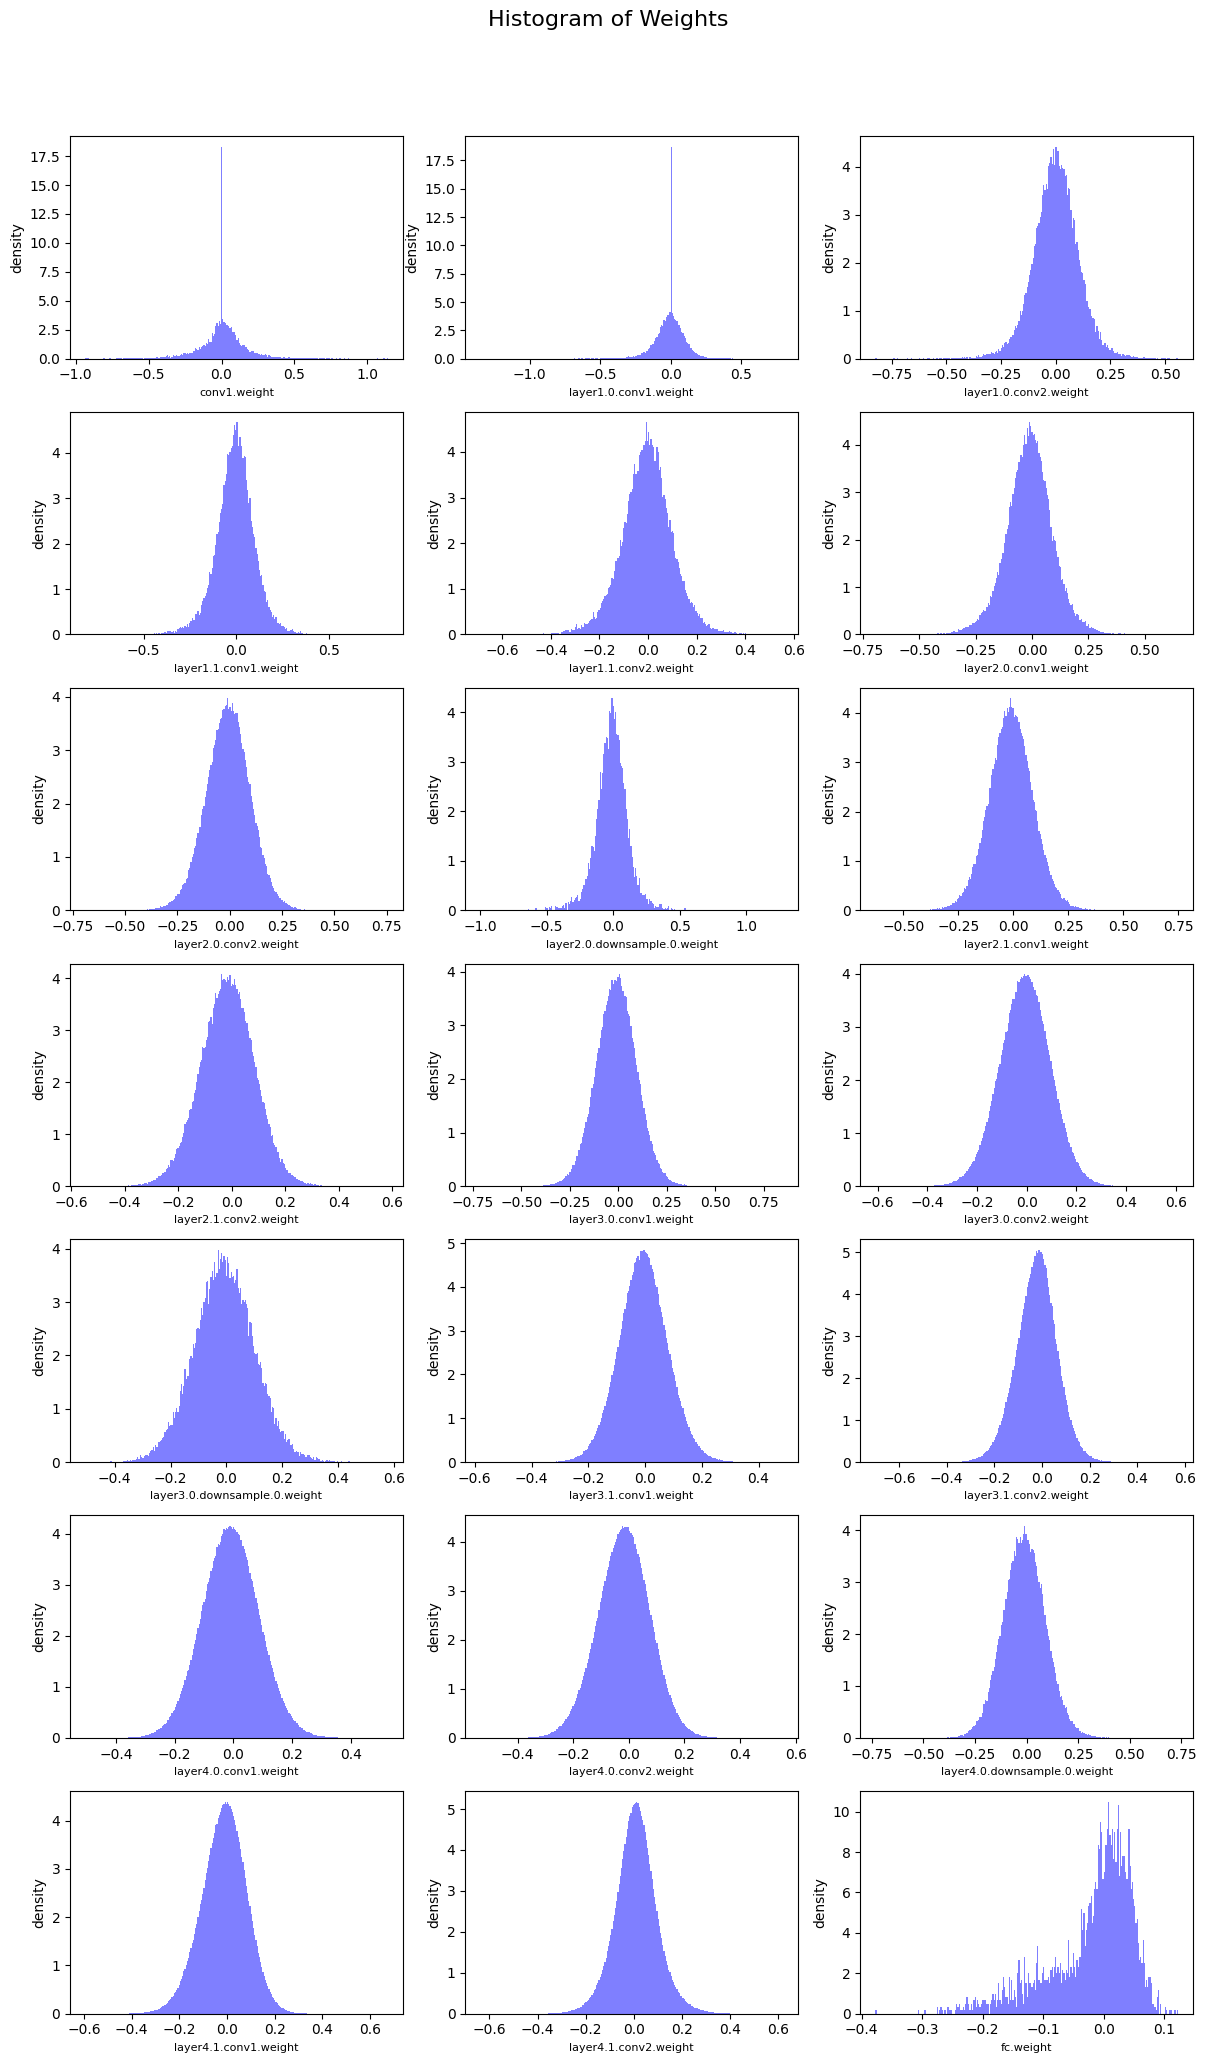

In [18]:
plot_weight_distribution(model)

## Sensitivity Scan


Different layers contribute differently to the model performance. It is challenging to decide the proper sparsity for each layer. A widely used approach is sensitivity scan.

During the sensitivity scan, at each time, we will only prune one layer to see the accuracy degradation. By scanning different sparsities, we could draw the sensitivity curve (i.e., accuracy vs. sparsity) of the corresponding layer.

Here is an example figure for sensitivity curves. The x-axis is the sparsity or the percentage of #parameters dropped (*i.e.*, sparsity). The y-axis is the validation accuracy. (This is Figure 6 in [Learning both Weights and Connections for Efficient
Neural Networks](https://arxiv.org/pdf/1506.02626.pdf))

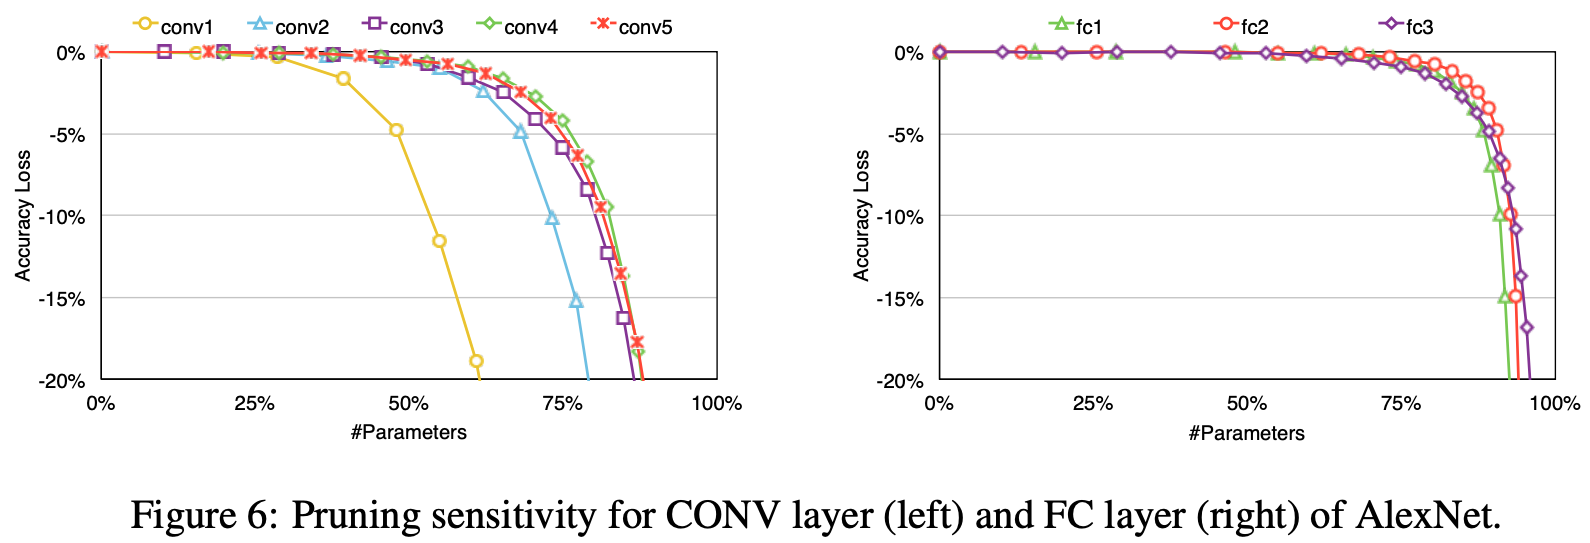

The following code cell runs the sensitivity scan function that returns the sparsities scanned, and a list of accuracies for each weight to be pruned.

In [20]:
sparsities, accuracies = sensitivity_scan(
    model, dataloader['test'], scan_step=0.1, scan_start=0.4, scan_end=1.0)

Layer 21/21: fc.weight: 100%|██████████| 6/6 [00:27<00:00,  4.58s/it]


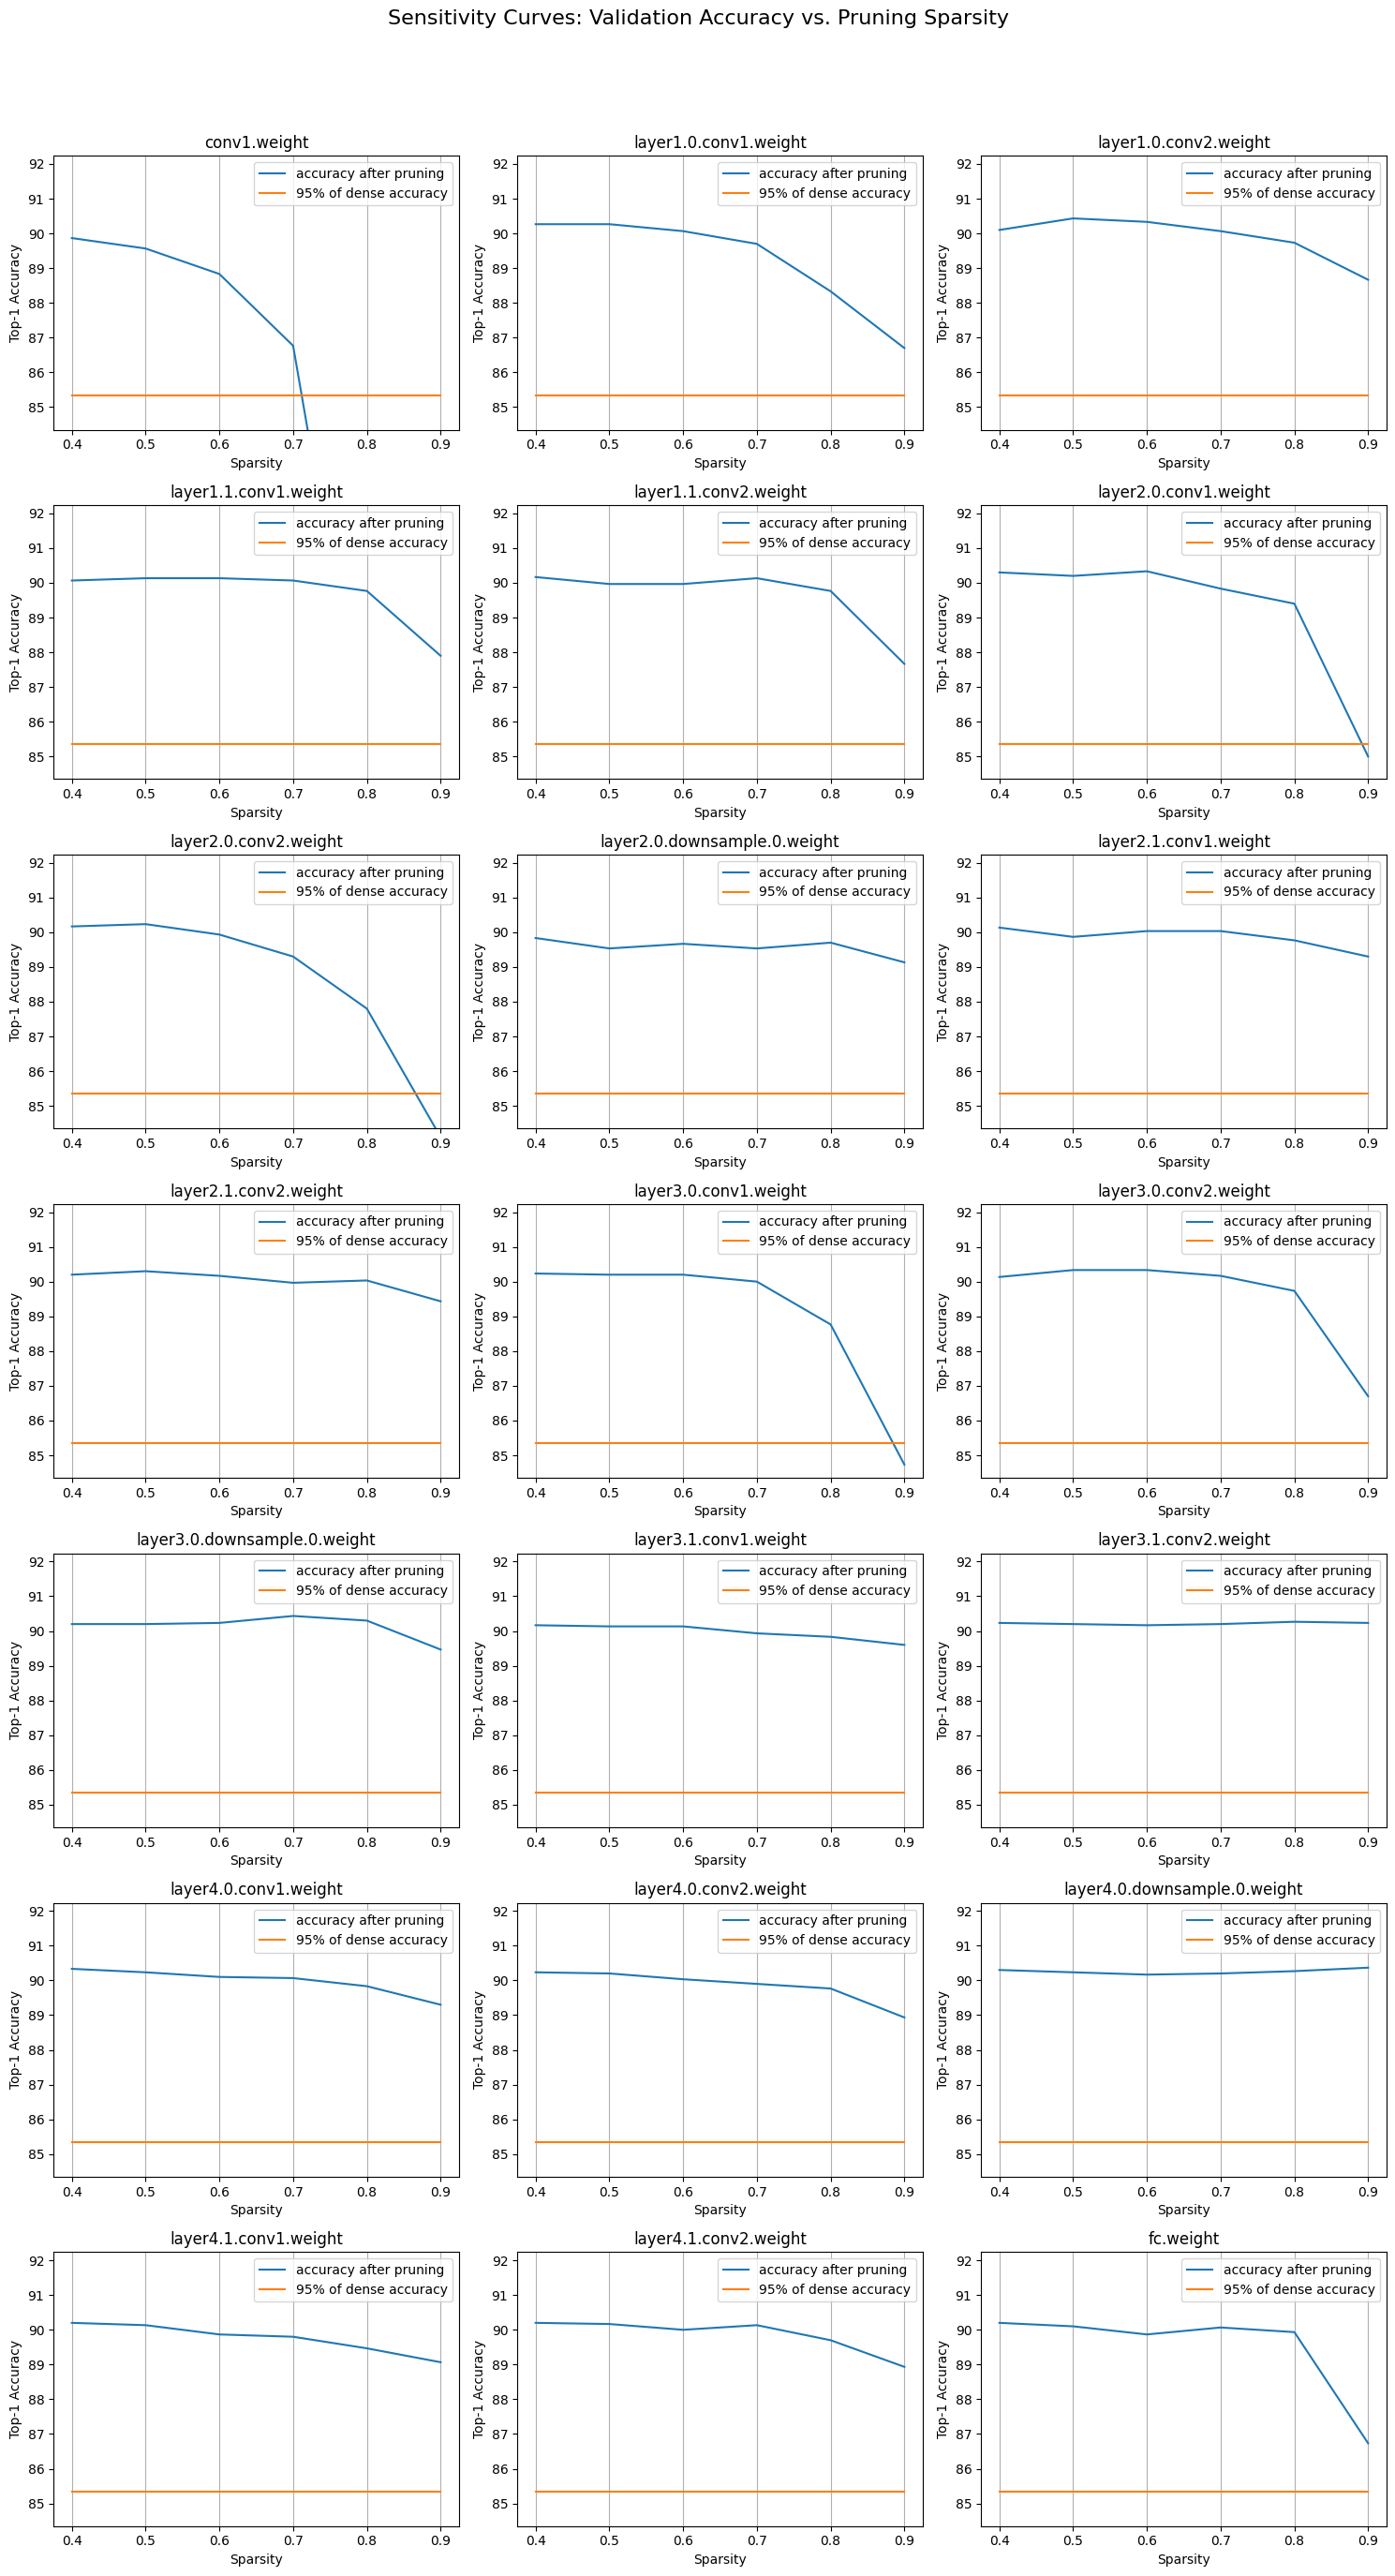

In [23]:
plot_sensitivity_scan(sparsities, accuracies, dense_model_accuracy, model)

## \#Parameters of each layer
In addition to accuracy, the number of each layer's parameters also affects the decision on sparsity selection. Layers with more #parameters require larger sparsities.

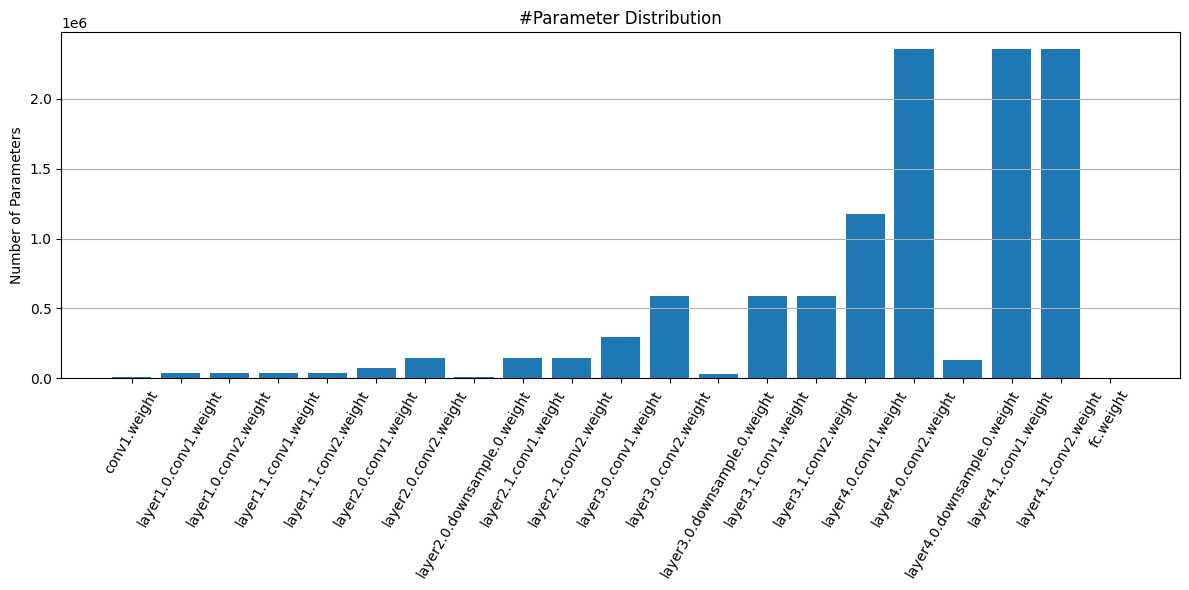

In [26]:

# update this also there. fig size increased
def plot_num_parameters_distribution(model):
    num_parameters = dict()
    for name, param in model.named_parameters():
        if param.dim() > 1:
            num_parameters[name] = param.numel()
    fig = plt.figure(figsize=(12, 6))
    plt.grid(axis='y')
    plt.bar(list(num_parameters.keys()), list(num_parameters.values()))
    plt.title('#Parameter Distribution')
    plt.ylabel('Number of Parameters')
    plt.xticks(rotation=60)
    plt.tight_layout()
    plt.show()

plot_num_parameters_distribution(model)

## Select Sparsity Based on Sensitivity Curves and \#Parameters Distribution

Based on the sensitivity curves and the distribution of #parameters in the model, please select the sparsity for each layer.

Note that the overall compression ratio of pruned model mostly depends on the layers with larger #parameters, and different layers have different sensitivity to pruning.
We make sure that after pruning, the sparse model is 25% of the size of the dense model, and validation accuracy is higher than 92.5 after finetuning.

**Hint**:
*   The layer with more #parameters should have larger sparsity. (see *Figure #Parameter Distribution*)
*   The layer that is sensitive to the pruning sparsity (i.e., the accuracy will drop quickly as sparsity becomes higher) should have smaller sparsity. (see *Figure Sensitivity Curves*)

In [9]:
recover_model()


sparsity_dict = {}
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        if "downsample" in name:
            sparsity_dict[f"{name}.weight"] = 0.8  # less pruning for downsample
        else:
            sparsity_dict[f"{name}.weight"] = 0.8
    elif isinstance(module, nn.Linear):
        sparsity_dict[f"{name}.weight"] = 0.8  # keep fc layer more intact
sparsity_dict

{'conv1.weight': 0.8,
 'layer1.0.conv1.weight': 0.8,
 'layer1.0.conv2.weight': 0.8,
 'layer1.1.conv1.weight': 0.8,
 'layer1.1.conv2.weight': 0.8,
 'layer2.0.conv1.weight': 0.8,
 'layer2.0.conv2.weight': 0.8,
 'layer2.0.downsample.0.weight': 0.8,
 'layer2.1.conv1.weight': 0.8,
 'layer2.1.conv2.weight': 0.8,
 'layer3.0.conv1.weight': 0.8,
 'layer3.0.conv2.weight': 0.8,
 'layer3.0.downsample.0.weight': 0.8,
 'layer3.1.conv1.weight': 0.8,
 'layer3.1.conv2.weight': 0.8,
 'layer4.0.conv1.weight': 0.8,
 'layer4.0.conv2.weight': 0.8,
 'layer4.0.downsample.0.weight': 0.8,
 'layer4.1.conv1.weight': 0.8,
 'layer4.1.conv2.weight': 0.8,
 'fc.weight': 0.8}

After pruning with sparsity dictionary
  conv1.weight: 0.80
  layer1.0.conv1.weight: 0.80
  layer1.0.conv2.weight: 0.80
  layer1.1.conv1.weight: 0.80
  layer1.1.conv2.weight: 0.80
  layer2.0.conv1.weight: 0.80
  layer2.0.conv2.weight: 0.80
  layer2.0.downsample.0.weight: 0.80
  layer2.1.conv1.weight: 0.80
  layer2.1.conv2.weight: 0.80
  layer3.0.conv1.weight: 0.80
  layer3.0.conv2.weight: 0.80
  layer3.0.downsample.0.weight: 0.80
  layer3.1.conv1.weight: 0.80
  layer3.1.conv2.weight: 0.80
  layer4.0.conv1.weight: 0.80
  layer4.0.conv2.weight: 0.80
  layer4.0.downsample.0.weight: 0.80
  layer4.1.conv1.weight: 0.80
  layer4.1.conv2.weight: 0.80
  fc.weight: 0.80
The sparsity of each layer becomes
  conv1.weight: 0.80
  layer1.0.conv1.weight: 0.80
  layer1.0.conv2.weight: 0.80
  layer1.1.conv1.weight: 0.80
  layer1.1.conv2.weight: 0.80
  layer2.0.conv1.weight: 0.80
  layer2.0.conv2.weight: 0.80
  layer2.0.downsample.0.weight: 0.80
  layer2.1.conv1.weight: 0.80
  layer2.1.conv2.weight: 0.8

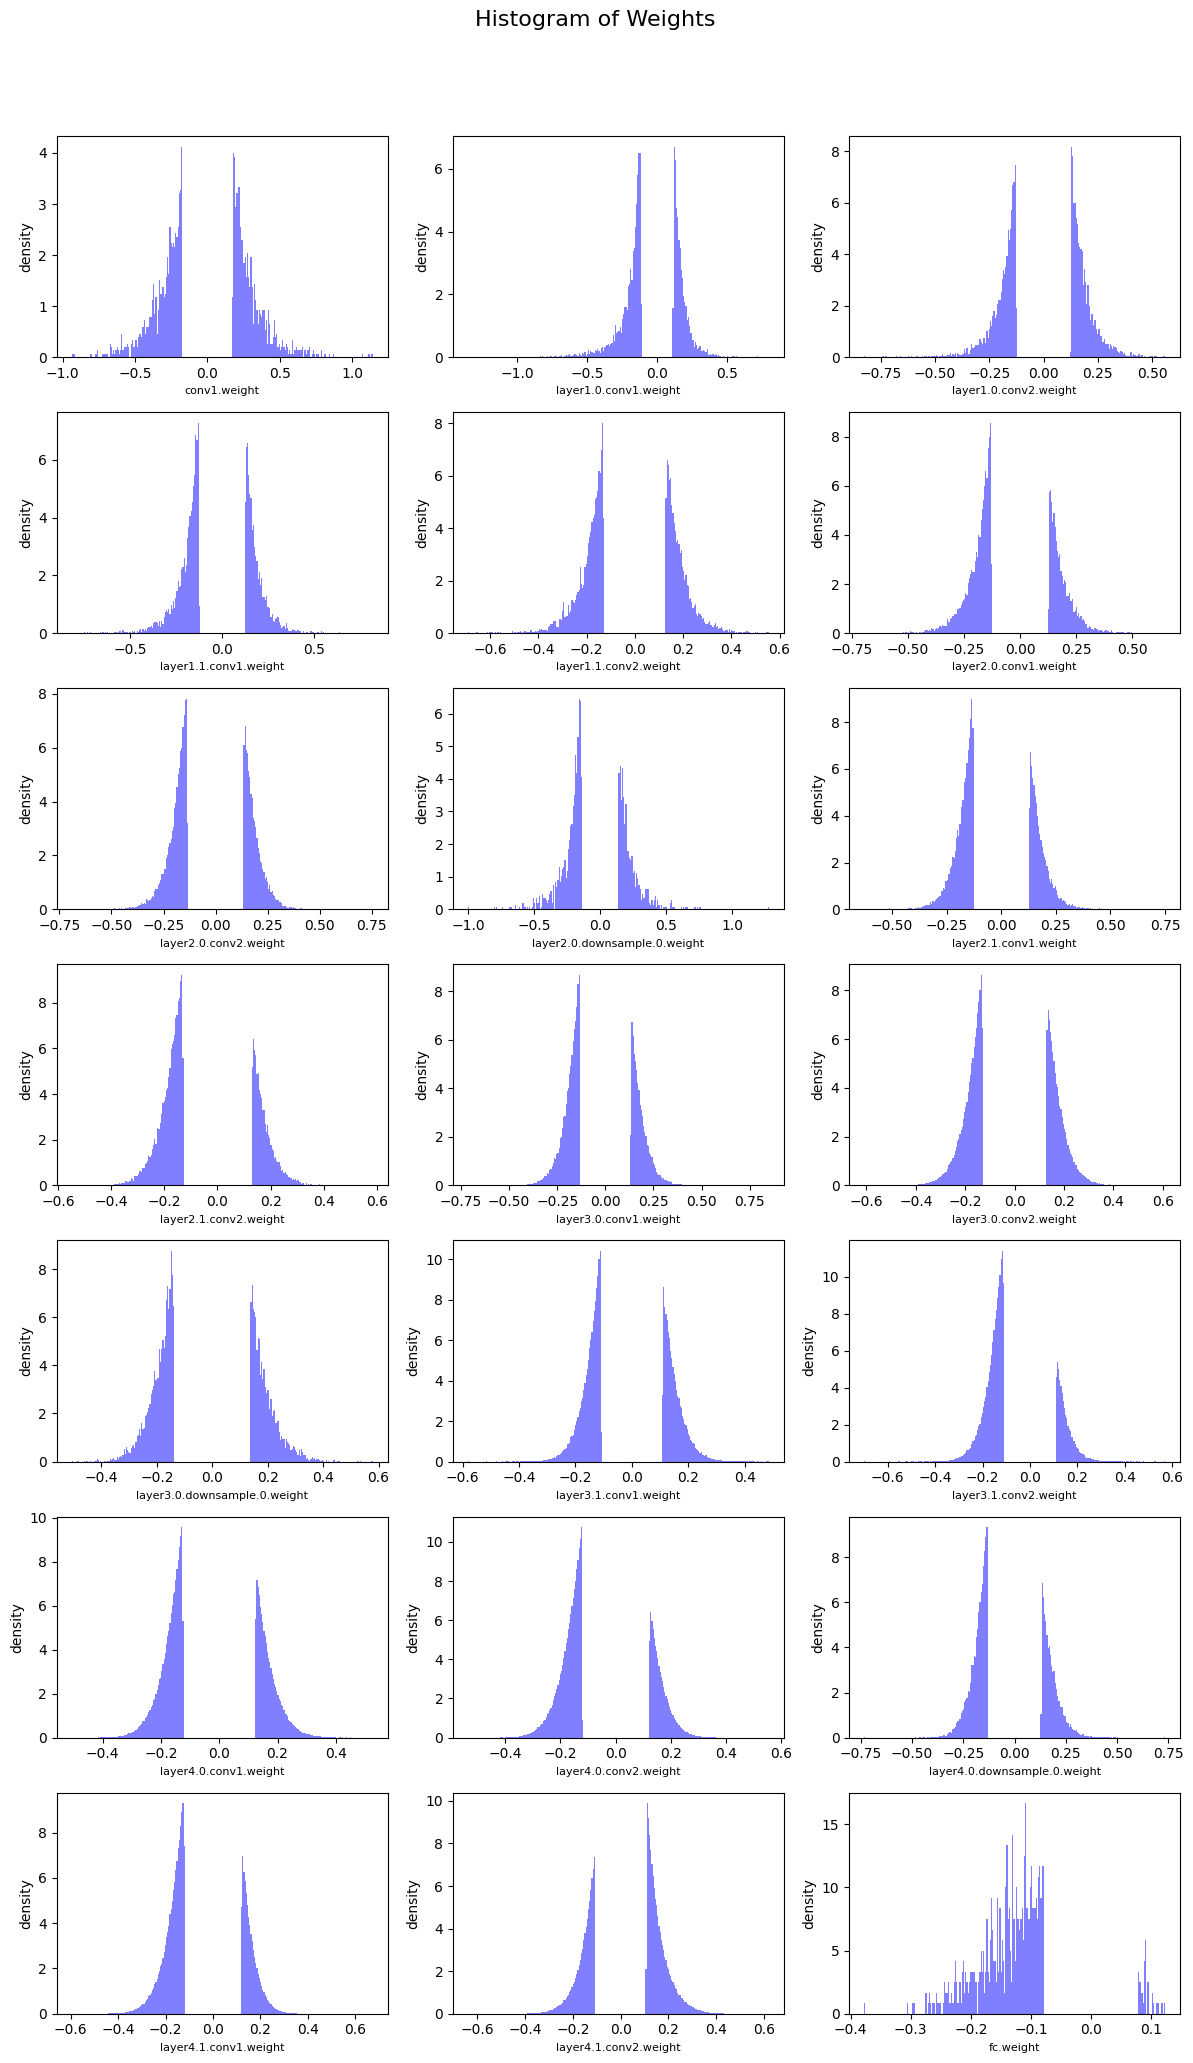

In [11]:
from pruner.pruner import FineGrainedPruner
pruner = FineGrainedPruner(model, sparsity_dict)
print(f'After pruning with sparsity dictionary')
for name, sparsity in sparsity_dict.items():
    print(f'  {name}: {sparsity:.2f}')
print(f'The sparsity of each layer becomes')
for name, param in model.named_parameters():
    if name in sparsity_dict:
        print(f'  {name}: {get_sparsity(param):.2f}')

sparse_model_size = get_model_size(model, count_nonzero_only=True)
print(f"Sparse model has size={sparse_model_size / MiB:.2f} MiB = {sparse_model_size / dense_model_size * 100:.2f}% of dense model size")
sparse_model_accuracy = evaluate(model, dataloader['test'])
print(f"Sparse model has accuracy={sparse_model_accuracy:.2f}% before fintuning")

plot_weight_distribution(model, count_nonzero_only=True)

## Finetune the fine-grained pruned model
As we can see from the outputs of previous cell, even though fine-grained pruning reduces the most of model weights, the accuracy of model also dropped. Therefore, we have to finetune the sparse model to recover the accuracy.

In [12]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_finetune_epochs = 5
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_finetune_epochs)




best_sparse_model_checkpoint = dict()
best_accuracy = 0
print(f'Finetuning Fine-grained Pruned Sparse Model')
for epoch in range(num_finetune_epochs):
    # At the end of each train iteration, we have to apply the pruning mask
    #    to keep the model sparse during the training
    train(model, dataloader['train'], criterion, optimizer, scheduler,
          callbacks=[lambda: pruner.apply(model)])
    accuracy = evaluate(model, dataloader['test'])
    is_best = accuracy > best_accuracy
    if is_best:
        best_sparse_model_checkpoint['state_dict'] = copy.deepcopy(model.state_dict())
        best_accuracy = accuracy
    print(f'    Epoch {epoch+1} Accuracy {accuracy:.2f}% / Best Accuracy: {best_accuracy:.2f}%')
# saving the pruned model

# prune_save_path = "/kaggle/working/making_models_efficient/pruning-resnet/model/resnet18_pruned.pth"

# torch.save(best_sparse_model_checkpoint, prune_save_path)
# print(f"Best pruned model saved!")

Finetuning Fine-grained Pruned Sparse Model


    Epoch 1 Accuracy 91.03% / Best Accuracy: 91.03%


    Epoch 2 Accuracy 91.13% / Best Accuracy: 91.13%


    Epoch 3 Accuracy 91.07% / Best Accuracy: 91.13%


    Epoch 4 Accuracy 90.80% / Best Accuracy: 91.13%


    Epoch 5 Accuracy 90.83% / Best Accuracy: 91.13%


In [13]:
# load the best sparse model checkpoint to evaluate the final performance
model.load_state_dict(best_sparse_model_checkpoint['state_dict'])
sparse_model_size = get_model_size(model, count_nonzero_only=True)
print(f"Sparse model has size={sparse_model_size / MiB:.2f} MiB = {sparse_model_size / dense_model_size * 100:.2f}% of dense model size")
sparse_model_accuracy = evaluate(model, dataloader['test'])
print(f"Sparse model has accuracy={sparse_model_accuracy:.2f}% after fintuning")

Sparse model has size=8.56 MiB = 20.07% of dense model size
Sparse model has accuracy=91.13% after fintuning


In [18]:
device = next(model.parameters()).device  # Get model device (cpu or cuda)

macs = get_model_macs(model, dummy_input) / 1e6
params = get_num_parameters(model) / 1e6
sparsity = get_model_sparsity(model) * 100

print(f"Model MACs: {macs:.2f} million")
print(f"Model parameters: {params:.2f} million")
print(f"Model sparsity: {sparsity:.2f}%")


sparse_model_size = get_model_size(model, count_nonzero_only=True)
print(f"Sparse model has size={sparse_model_size / MiB:.2f} MiB = {sparse_model_size / dense_model_size * 100:.2f}% of dense model size")

sparse_model_accuracy = evaluate(model, dataloader['test'])
print(f"Sparse model has accuracy={sparse_model_accuracy:.2f}% after finetuning")


Model MACs: 875.70 million
Model parameters: 11.18 million
Model sparsity: 79.93%
Sparse model has size=8.56 MiB = 20.07% of dense model size
Sparse model has accuracy=91.13% after finetuning
